In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import  sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings("ignore")



In [193]:
#loading the data
conn=sqlite3.connect(r"C:\Users\ASUS\Downloads\data\data\inventory.db")
# fetching vendor summary dat

df=pd.read_sql_query("select* from vendor_sales_summary_orignal",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [ ]:
# =============================================================================
#                    EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================
#
# Before starting EDA, we completed an ETL (Extract, Transform, Load) pipeline.
#
# What we did previously:
#
# 1. Extract
#    - Loaded data from multiple SQLite tables:
#         • purchases
#         • purchase_prices
#         • sales
#         • vendor_invoice
#    - Used SQL JOINs, GROUP BY, and aggregations to merge these tables into
#      a single consolidated vendor sales summary.
#
# 2. Transform
#    - Cleaned the dataset by:
#         • Converting Volume to float
#         • Filling missing values with 0
#         • Removing unwanted spaces from text columns
#
#    - Performed Feature Engineering by creating new business metrics:
#         • GrossProfit
#         • ProfitMargin
#         • StockTurnover
#         • SalesToPurchaseRatio
#
# 3. Load
#    - Saved the cleaned and transformed dataset back into SQLite as:
#         vendor_sales_summary_original
#
# ---------------------------------------------------------------------------
# What is EDA?
#
# Exploratory Data Analysis (EDA) is the process of understanding the
# processed dataset before building dashboards or predictive models.
#
# During EDA we will:
#
# • Understand the structure of the data
# • Check data types and missing values
# • Study the distribution of numerical features
# • Analyze categorical variables
# • Detect outliers and anomalies
# • Find relationships between variables
# • Generate business insights and trends
#
# The objective of EDA is to ensure data quality, validate the results of
# our ETL pipeline, and discover meaningful patterns that can support
# business decision-making.
# =============================================================================

In [23]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


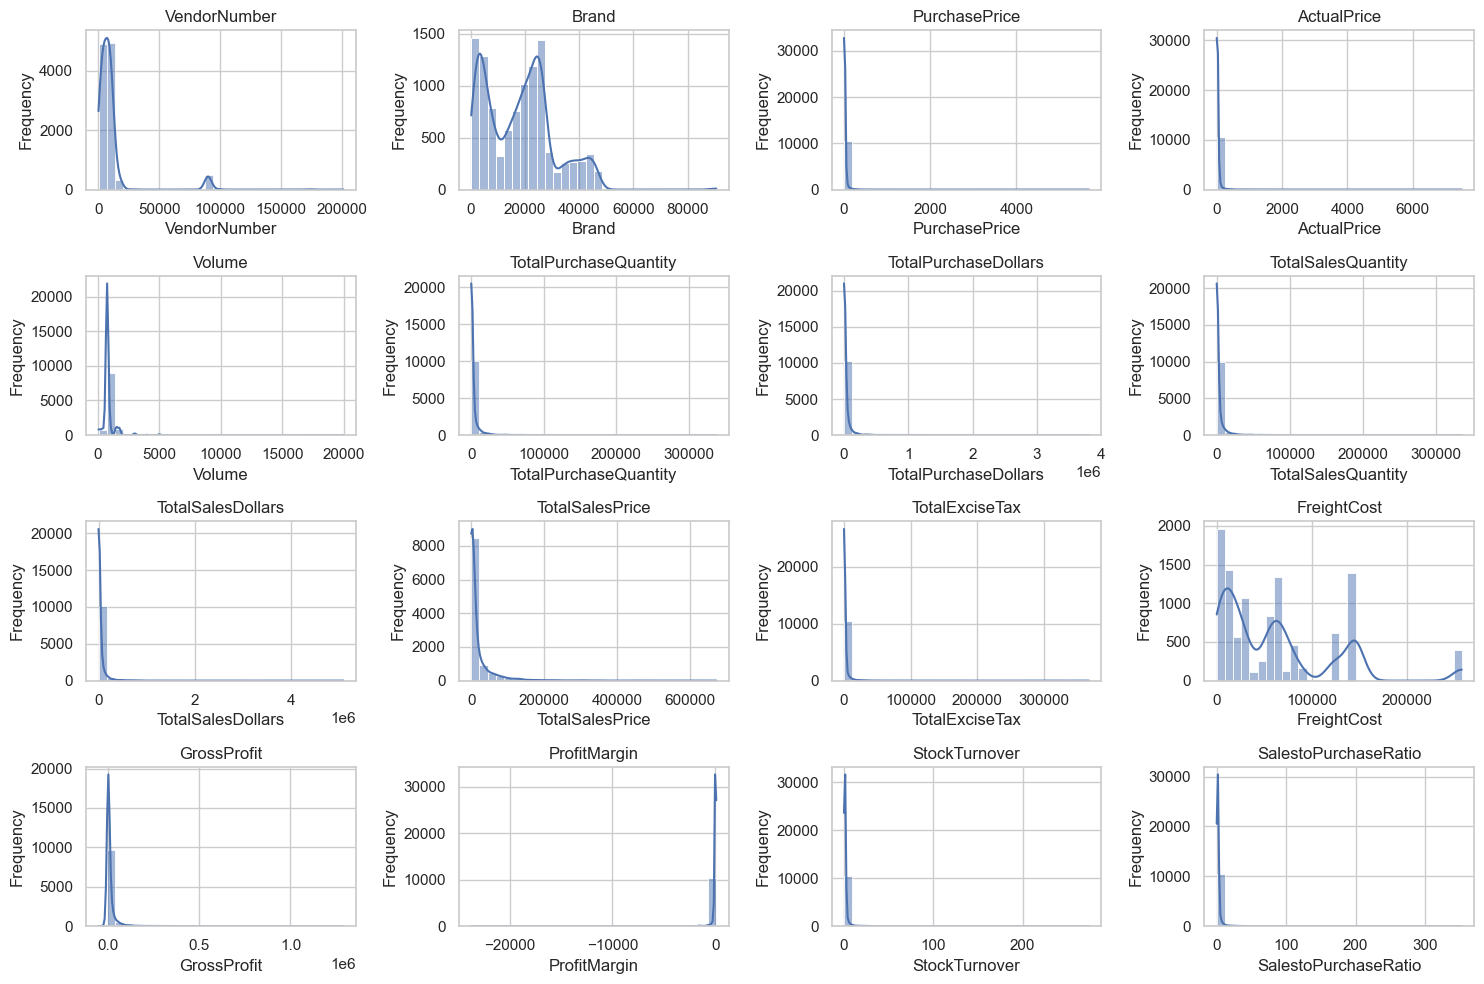

In [194]:
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
  plt.subplot(4,4,i+1)
  sns.histplot(df[col],kde=True,bins=30)
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.tight_layout()
plt.show()

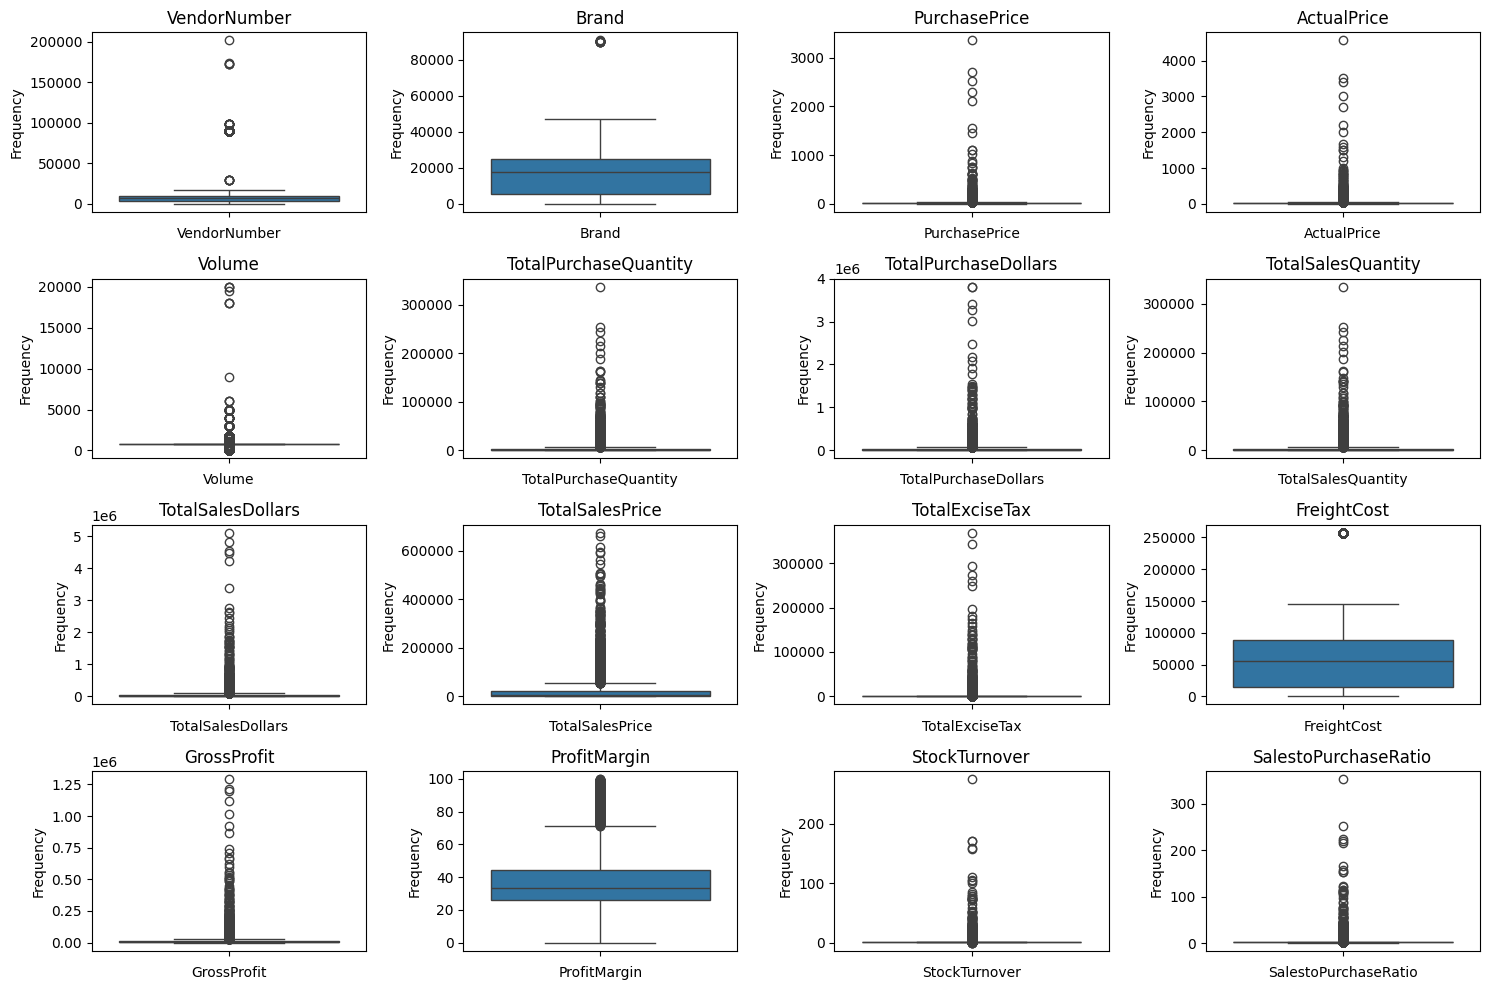

In [38]:
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
  plt.subplot(4,4,i+1)
  sns.boxplot(df[col])
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.tight_layout()
plt.show()

In [36]:
df=pd.read_sql_query("""SELECT * FROM vendor_sales_summary_orignal
                     where grossprofit>0
                     and profitmargin>0
                     and totalsalesquantity>0 """, conn)
df


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


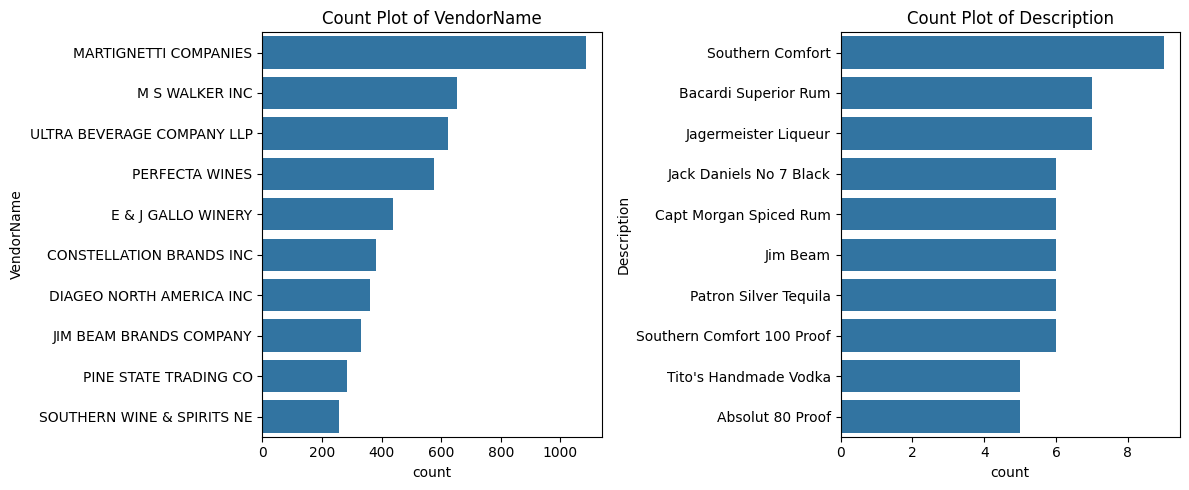

In [39]:
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]
    )
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

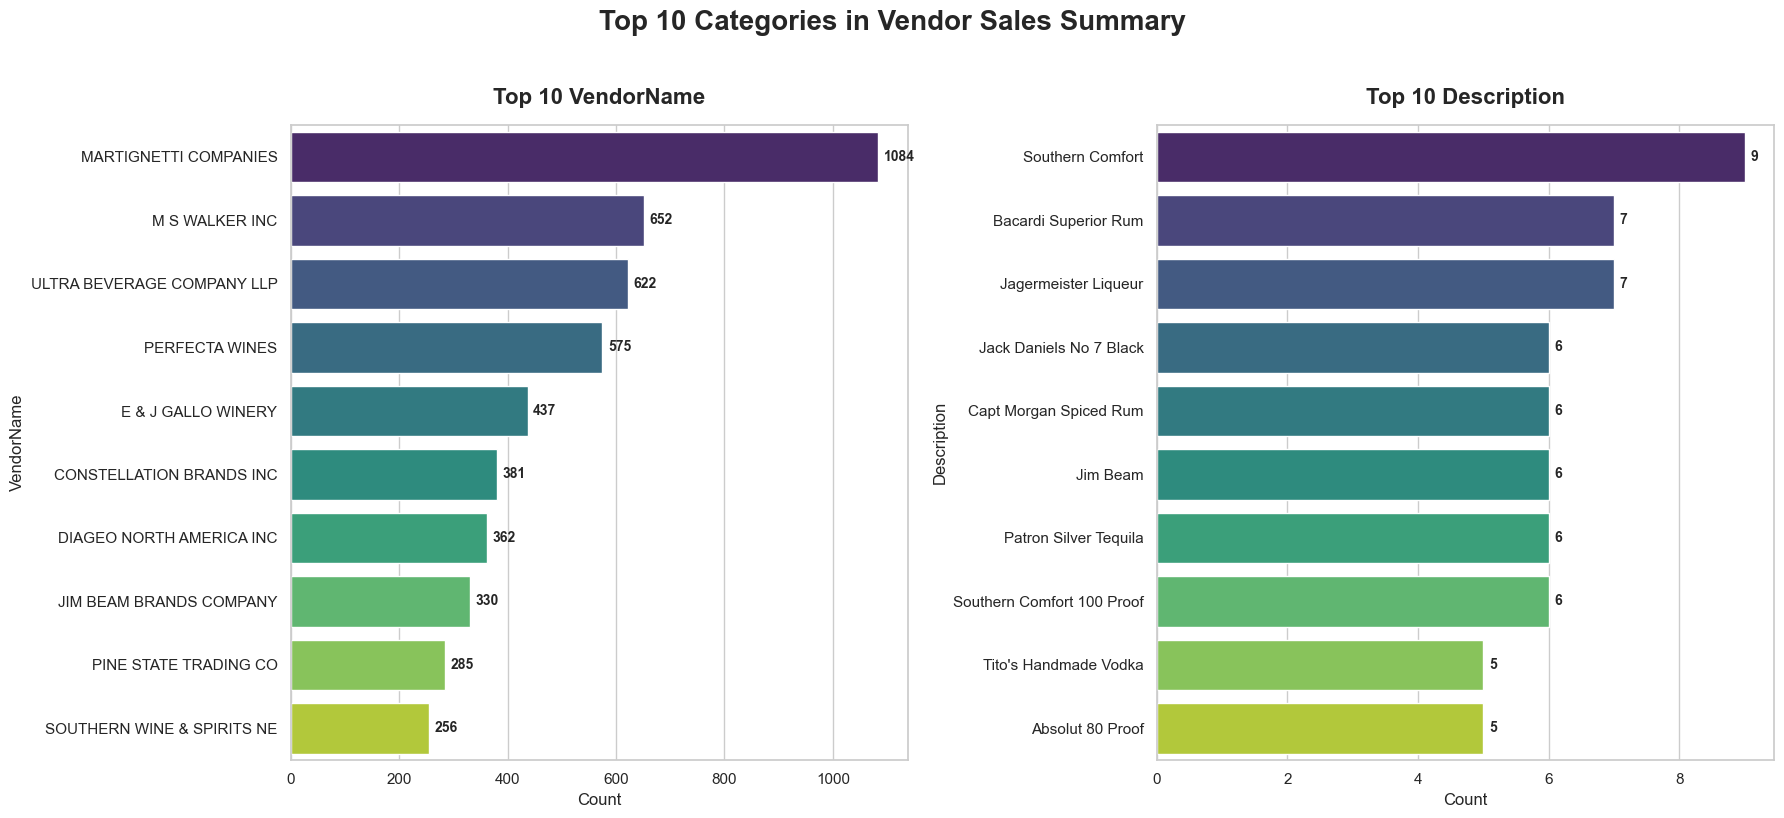

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ["VendorName", "Description"]

# Professional theme
sns.set_theme(style="whitegrid", palette="viridis")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for i, col in enumerate(categorical_cols):

    top10 = df[col].value_counts().head(10)

    sns.barplot(
        x=top10.values,
        y=top10.index,
        ax=axes[i],
        hue=top10.index,
        palette="viridis",
        legend=False
    )

    axes[i].set_title(
        f"Top 10 {col}",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    axes[i].set_xlabel("Count", fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

    # Add count labels on each bar
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt="%d",
            padding=4,
            fontsize=10,
            fontweight="bold"
        )

plt.suptitle(
    "Top 10 Categories in Vendor Sales Summary",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

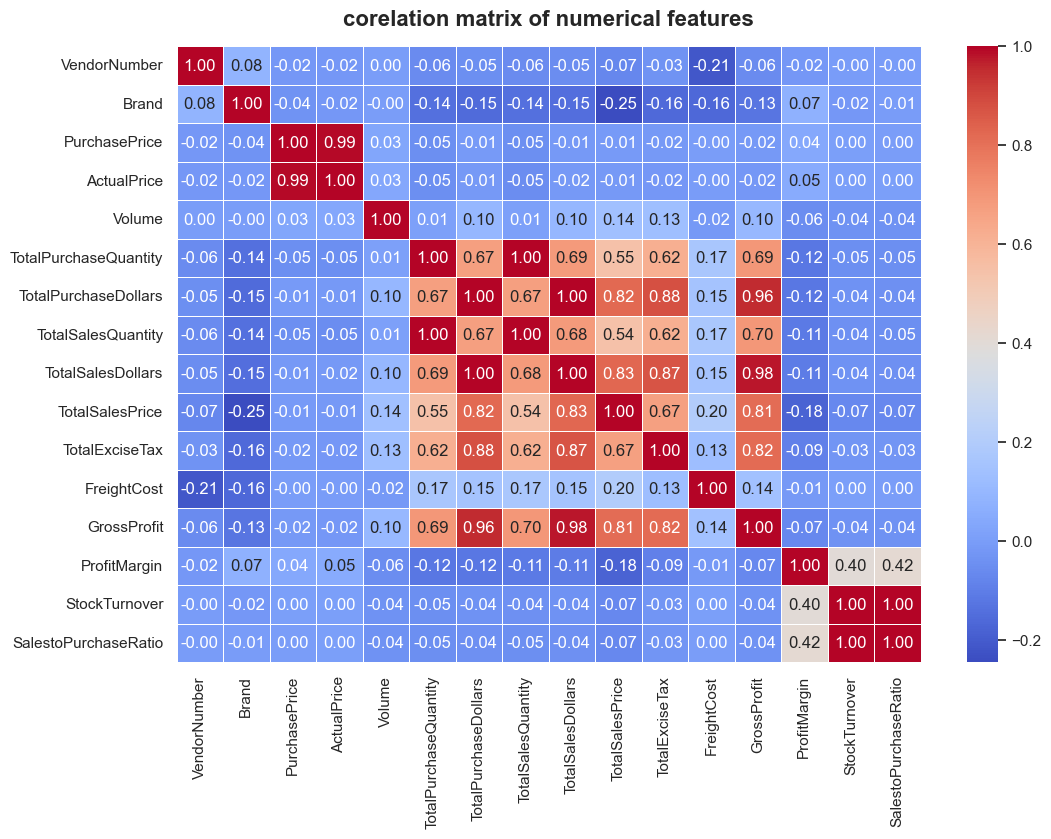

In [42]:
#corelation plot heatmap
plt.figure(figsize=(12,8))
corelation_matrix=df[numerical_cols].corr()
sns.heatmap(corelation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("corelation matrix of numerical features",fontsize=16,fontweight="bold",pad=15)
plt.show()

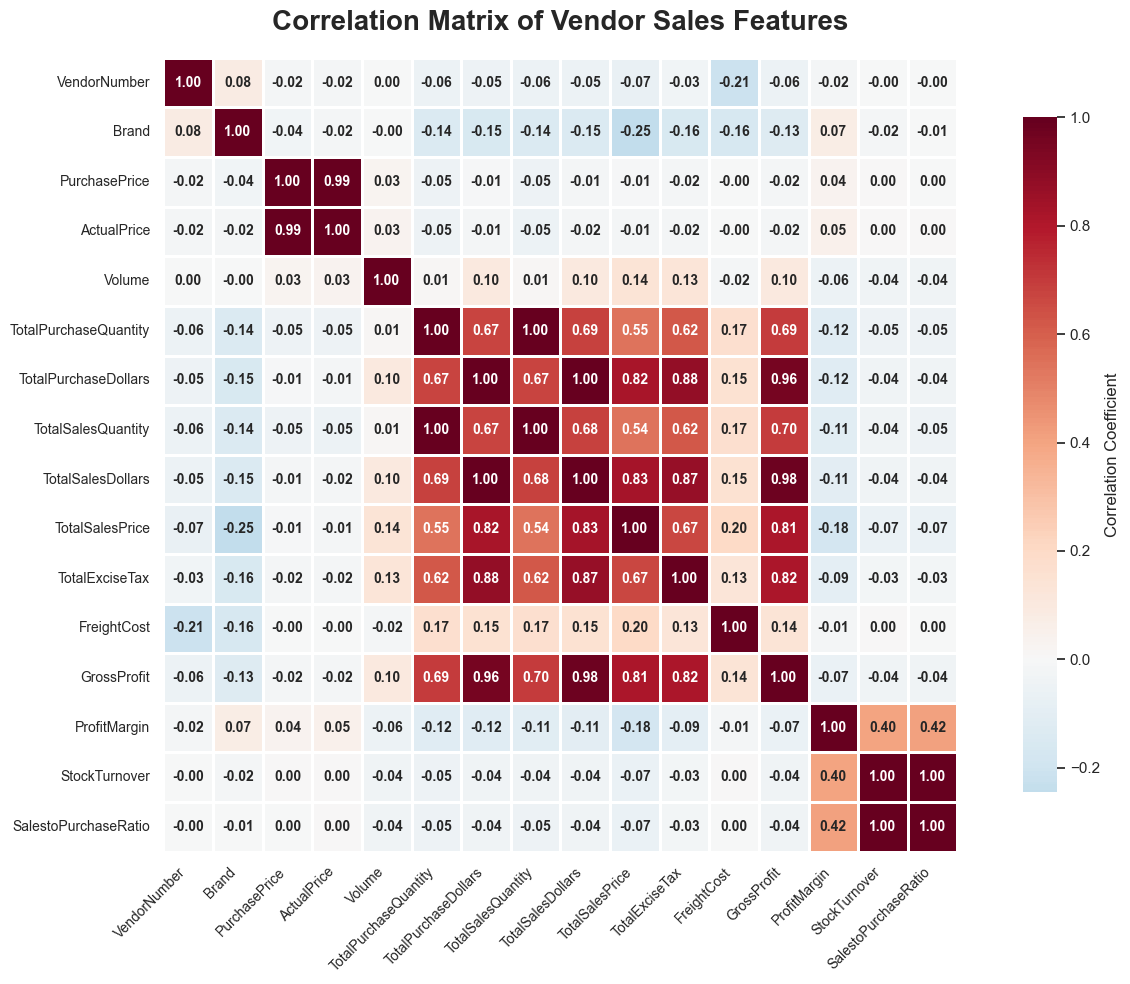

In [43]:
#advance version of heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

# Professional plotting style
sns.set_theme(style="white")

# Compute correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create figure
plt.figure(figsize=(14, 10))

# Plot heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={
        "size": 10,
        "weight": "bold"
    },
    cbar_kws={
        "label": "Correlation Coefficient",
        "shrink": 0.85
    }
)

# Title
plt.title(
    "Correlation Matrix of Vendor Sales Features",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Axis formatting
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Improve spacing
plt.tight_layout()

# Display
plt.show()

In [67]:
#identify brands whose sales perfomance is low but profit margin are higher as these brands need pricing adjustment 
#and promotional adjust ment
brand_perfomance=df.groupby('Description').agg({'TotalSalesDollars':'sum',
                                               'ProfitMargin':'mean'}).reset_index()


In [62]:
#low sales thresold is 15%
low_sales_threshold=brand_perfomance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_perfomance['ProfitMargin'].quantile(0.85)
low_sales_threshold


np.float64(560.299)

In [63]:
high_margin_threshold

np.float64(64.97017552750113)

In [68]:
# Filter brands with low sales but high profit margins
target_brands = brand_perfomance[
    (brand_perfomance["TotalSalesDollars"] <= low_sales_threshold) &
    (brand_perfomance["ProfitMargin"] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")

display(
    target_brands.sort_values("TotalSalesDollars")
)

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


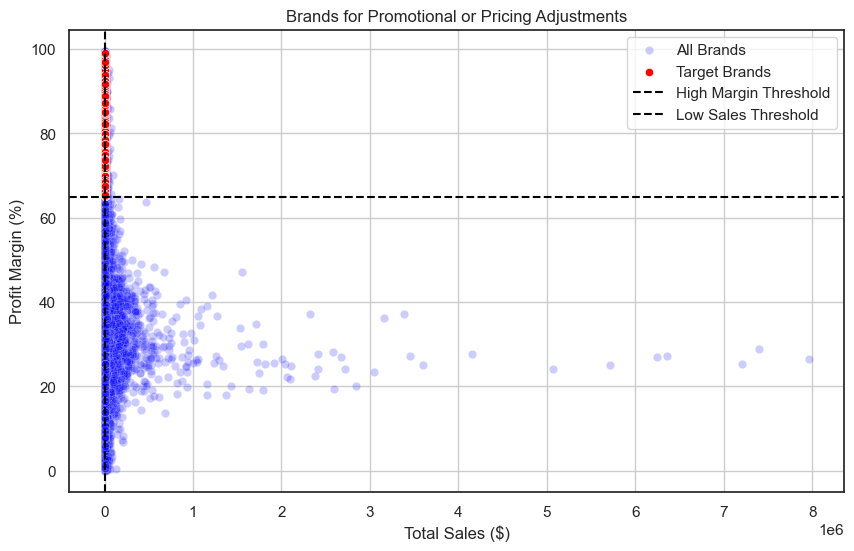

In [69]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_perfomance,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="blue",
    label="All Brands",
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="red",
    label="Target Brands"
)

plt.axhline(
    high_margin_threshold,
    linestyle="--",
    color="black",
    label="High Margin Threshold"
)

plt.axvline(
    low_sales_threshold,
    linestyle="--",
    color="black",
    label="Low Sales Threshold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")

plt.legend()
plt.grid(True)

plt.show()

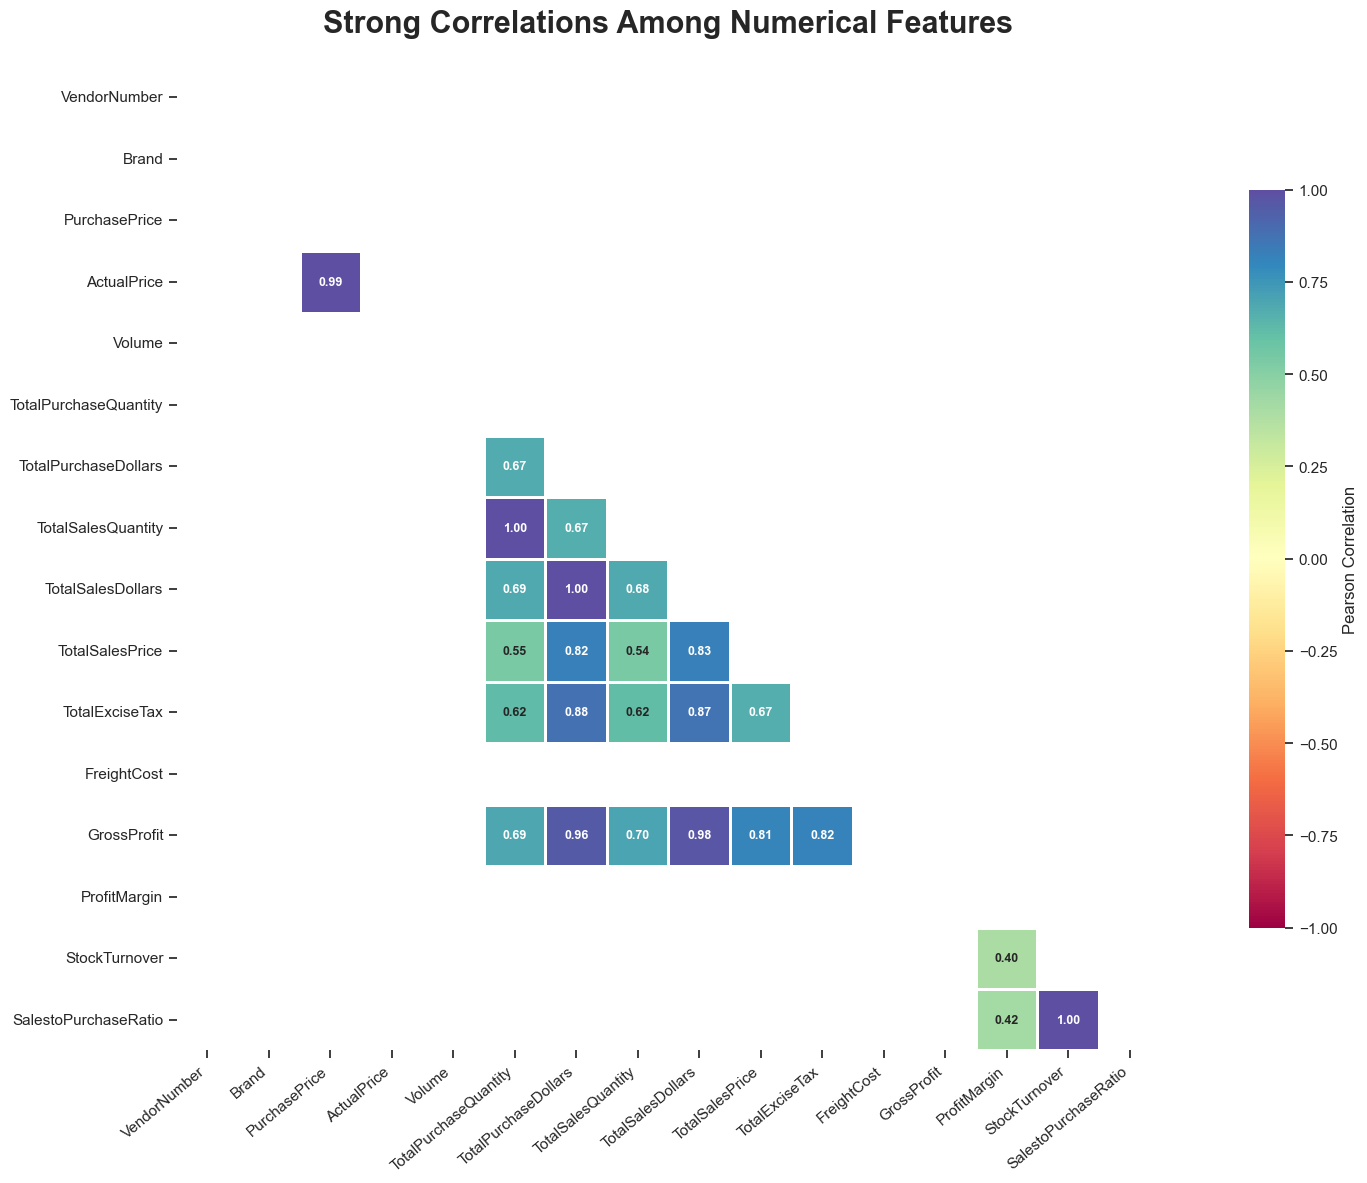

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.select_dtypes(include=np.number).corr()

# Keep only strong correlations
corr_filtered = corr.where(abs(corr) >= 0.30)

mask = np.triu(np.ones_like(corr_filtered, dtype=bool))

sns.set_theme(style="ticks")

plt.figure(figsize=(18,12))

sns.heatmap(
    corr_filtered,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    center=0,
    square=True,
    linewidths=1,
    linecolor="white",
    vmin=-1,
    vmax=1,
    annot_kws={
        "fontsize":9,
        "fontweight":"bold"
    },
    cbar_kws={
        "label":"Pearson Correlation",
        "shrink":0.75
    }
)

plt.title(
    "Strong Correlations Among Numerical Features",
    fontsize=22,
    weight="bold",
    pad=25
)

plt.xticks(rotation=40, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

plt.show()

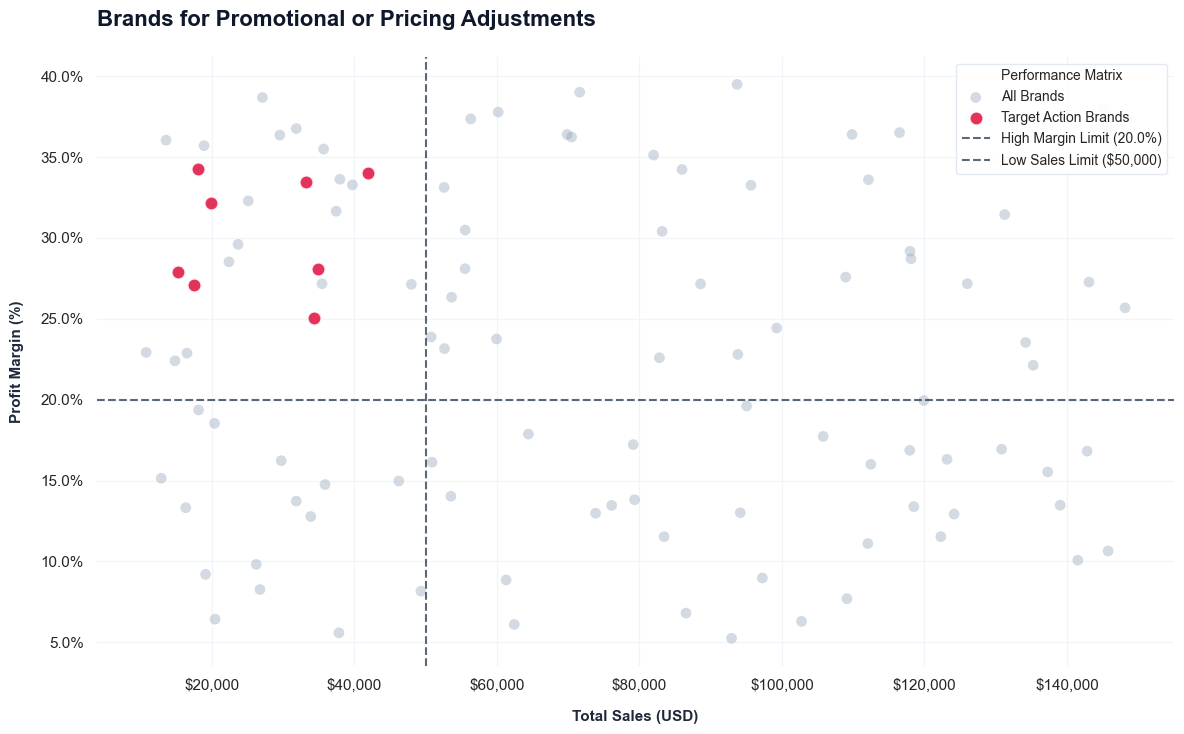

In [75]:
import os
from typing import Optional
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# --- 1. THE FUNCTION DEFINITION ---
def plot_brand_performance_analysis(
    brand_performance: pd.DataFrame,
    target_brands: pd.DataFrame,
    high_margin_threshold: float,
    low_sales_threshold: float,
    title: str = "Brands for Promotional or Pricing Adjustments",
    save_path: Optional[str] = None,
) -> None:
    
    sns.set_theme(
        style="whitegrid",
        rc={
            "font.family": "sans-serif",
            "grid.color": "#f1f5f9",
            "axes.edgecolor": "#cbd5e1",
        },
    )

    fig, ax = plt.subplots(figsize=(12, 7.5), dpi=100) # Lowered DPI slightly for faster notebook rendering

    # Layer 1: All Brands (Context)
    sns.scatterplot(
        data=brand_performance,
        x="TotalSalesDollars",
        y="ProfitMargin",
        color="#94a3b8",
        alpha=0.4,
        edgecolor="none",
        s=60,
        label="All Brands",
        ax=ax,
    )

    # Layer 2: Target Brands (Focus)
    sns.scatterplot(
        data=target_brands,
        x="TotalSalesDollars",
        y="ProfitMargin",
        color="#e11d48",
        alpha=0.9,
        edgecolor="#ffffff",
        linewidth=1.5,
        s=100,
        label="Target Action Brands",
        ax=ax,
    )

    # Layer 3: Thresholds
    ax.axhline(
        y=high_margin_threshold,
        linestyle="--",
        color="#334155",
        linewidth=1.5,
        alpha=0.8,
        label=f"High Margin Limit ({high_margin_threshold}%)",
    )
    ax.axvline(
        x=low_sales_threshold,
        linestyle="--",
        color="#334155",
        linewidth=1.5,
        alpha=0.8,
        label=f"Low Sales Limit (${low_sales_threshold:,.0f})",
    )

    # Formatting
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y:.1f}%"))

    ax.set_xlabel("Total Sales (USD)", fontsize=11, fontweight="bold", labelpad=12, color="#1e293b")
    ax.set_ylabel("Profit Margin (%)", fontsize=11, fontweight="bold", labelpad=12, color="#1e293b")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=22, color="#0f172a", loc="left")

    sns.despine(left=True, bottom=True)

    ax.legend(
        loc="upper right",
        frameon=True,
        facecolor="#ffffff",
        edgecolor="#e2e8f0",
        framealpha=0.95,
        fontsize=10,
        title="Performance Matrix",
        title_fontsize=10,
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✅ Professional graph successfully exported to: {save_path}")
        plt.close(fig)
    else:
        plt.show() # <--- This makes it pop up on your screen!


# --- 2. GENERATE DUMMY DATA TO TEST IT ---
np.random.seed(42)

# Create mock data for all brands
all_sales = np.random.uniform(10000, 150000, 100)
all_margins = np.random.uniform(5, 40, 100)
df_all = pd.DataFrame({"TotalSalesDollars": all_sales, "ProfitMargin": all_margins})

# Create mock data for targeted exception brands
target_sales = np.random.uniform(15000, 45000, 8)
target_margins = np.random.uniform(25, 38, 8)
df_target = pd.DataFrame({"TotalSalesDollars": target_sales, "ProfitMargin": target_margins})

# --- 3. RUN THE EXECUTION ---
# Make sure save_path is left out or set to None so it renders inline!
plot_brand_performance_analysis(
    brand_performance=df_all,
    target_brands=df_target,
    high_margin_threshold=20.0,
    low_sales_threshold=50000,
    save_path=None 
)

In [76]:
#which vendors aand brands demonstarte highest sales perfomance?
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)



In [77]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [78]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

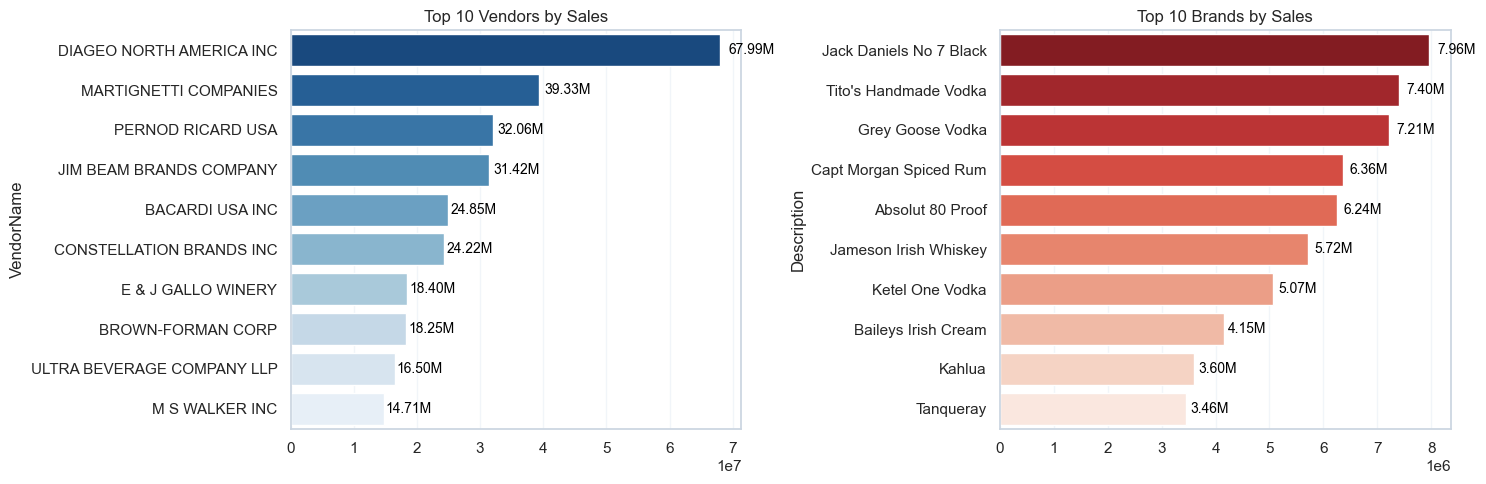

In [79]:
plt.figure(figsize=(15, 5))

# ==========================================================
# Plot for Top Vendors
# ==========================================================

plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:

    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )


# ==========================================================
# Plot for Top Brands
# ==========================================================

plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:

    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )

plt.tight_layout()

plt.show()

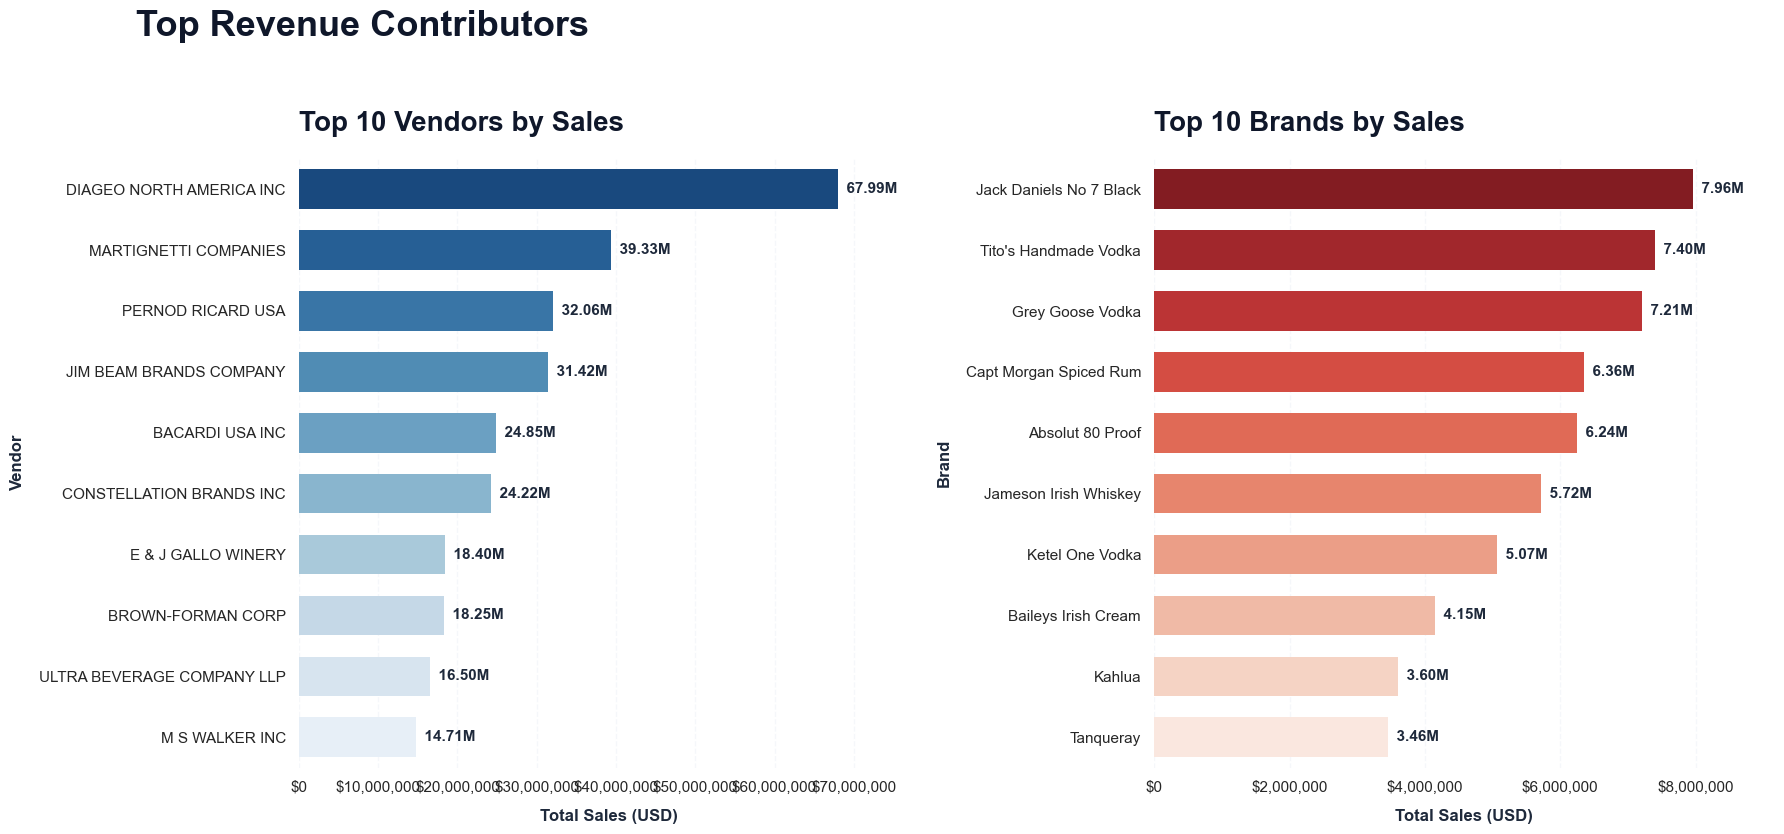

In [81]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ==========================================================
# 1. Premium Global Design Settings
# ==========================================================
# Switching to a clean white canvas with refined sans-serif typography
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "grid.color": "#f1f5f9",  # Soft slate gridlines
        "axes.edgecolor": "#e2e8f0",
    },
)

# Initialize the canvas with a high-resolution DPI for crisp rendering
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor="#ffffff", dpi=100)

# Define clean semantic corporate colors (Slate text, soft gray bars)
TEXT_COLOR = "#1e293b"
TITLE_COLOR = "#0f172a"

# ==========================================================
# 2. Top 10 Vendors Visualization
# ==========================================================
df_vendors = top_vendors.reset_index()
vendor_x_col = top_vendors.values
vendor_y_col = top_vendors.index

ax1 = sns.barplot(
    data=df_vendors,
    x=vendor_x_col,
    y=vendor_y_col,
    palette="Blues_r",
    ax=axes[0],
    width=0.65,  # Add breathing room between horizontal bars
    edgecolor="none",
)

# Editorial, modern left-aligned typography layout
axes[0].set_title(
    "Top 10 Vendors by Sales",
    fontsize=20,
    fontweight="bold",
    pad=20,
    color=TITLE_COLOR,
    loc="left",
)

axes[0].set_xlabel("Total Sales (USD)", fontsize=12, fontweight="bold", labelpad=10, color=TEXT_COLOR)
axes[0].set_ylabel("Vendor", fontsize=12, fontweight="bold", labelpad=10, color=TEXT_COLOR)

# Dynamically pad the X-axis limit to prevent data text labels from clipping
axes[0].set_xlim(0, max(vendor_x_col) * 1.15)

# Format the background x-axis tick labels to clean currency strings
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))

# Precision text placement loop
for bar in ax1.patches:
    width = bar.get_width()
    if width > 0:
        ax1.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f"  {format_dollars(width)}",
            va="center",
            ha="left",
            fontsize=11,
            fontweight="600",
            color=TEXT_COLOR,
        )

# Clean up layout grid and remove container borders
axes[0].grid(axis="y", visible=False)  # Remove horizontal lines, keep vertical ones
axes[0].grid(axis="x", linestyle="--", alpha=0.7)
sns.despine(ax=axes[0], left=True, bottom=True)

# ==========================================================
# 3. Top 10 Brands Visualization
# ==========================================================
df_brands = top_brands.reset_index()
brand_x_col = top_brands.values
brand_y_col = top_brands.index.astype(str)

ax2 = sns.barplot(
    data=df_brands,
    x=brand_x_col,
    y=brand_y_col,
    palette="Reds_r",
    ax=axes[1],
    width=0.65,
    edgecolor="none",
)

axes[1].set_title(
    "Top 10 Brands by Sales",
    fontsize=20,
    fontweight="bold",
    pad=20,
    color=TITLE_COLOR,
    loc="left",
)

axes[1].set_xlabel("Total Sales (USD)", fontsize=12, fontweight="bold", labelpad=10, color=TEXT_COLOR)
axes[1].set_ylabel("Brand", fontsize=12, fontweight="bold", labelpad=10, color=TEXT_COLOR)

# Dynamically pad the X-axis limit
axes[1].set_xlim(0, max(brand_x_col) * 1.15)

# Format background x-axis ticks
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))

# Precision text placement loop
for bar in ax2.patches:
    width = bar.get_width()
    if width > 0:
        ax2.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f"  {format_dollars(width)}",
            va="center",
            ha="left",
            fontsize=11,
            fontweight="600",
            color=TEXT_COLOR,
        )

# Clean up layout grid and remove container borders
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", linestyle="--", alpha=0.7)
sns.despine(ax=axes[1], left=True, bottom=True)

# ==========================================================
# 4. Master Title and Layout Finalization
# ==========================================================
fig.suptitle(
    "Top Revenue Contributors",
    fontsize=26,
    fontweight="bold",
    color=TITLE_COLOR,
    y=1.04,
    x=0.08,  # Align perfectly to the left edge of the plots
    ha="left",
)

plt.tight_layout()
plt.show()

In [97]:
#which vendors contributes most to total sales purchase dollars ?
vendor_perfomance=df.groupby('VendorName').agg({
  'TotalPurchaseDollars':'sum',
  'GrossProfit':'sum',
  'TotalSalesDollars':'sum'

}).reset_index()
vendor_perfomance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [102]:
vendor_perfomance["PurchaseContribution%"] = (
    vendor_perfomance["TotalPurchaseDollars"]
    / vendor_perfomance["TotalPurchaseDollars"].sum()
)


In [127]:
vendor_perfomance=round(vendor_perfomance.sort_values('PurchaseContribution%',ascending=False),2)

In [128]:
# Display Top 10 Vendors

top_vendors = vendor_perfomance.head(10)

top_vendors["TotalSalesDollars"] = (
    top_vendors["TotalSalesDollars"].apply(format_dollars)
)

top_vendors["TotalPurchaseDollars"] = (
    top_vendors["TotalPurchaseDollars"].apply(format_dollars)
)

top_vendors["GrossProfit"] = (
    top_vendors["GrossProfit"].apply(format_dollars)
)

display(top_vendors)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04
53,M S WALKER INC,9.76M,4.94M,14.71M,0.03


In [129]:
vendor_perfomance.shape

(119, 5)

In [130]:
top_vendors['PurchaseContribution%'].sum

<bound method Series.sum of 25     0.16
57     0.08
68     0.08
46     0.08
6      0.06
20     0.05
11     0.04
30     0.04
106    0.04
53     0.03
Name: PurchaseContribution%, dtype: float64>

In [131]:
top_vendors['PurchaseContribution%'].sum()
# this means from the whole lot of vendors top 10 vendors contribution is m,ore than 60 percent a valuabale insisght

np.float64(0.6600000000000001)

In [169]:
top_vendors['cumulative_contribution%']=top_vendors['PurchaseContribution%'].cumsum()*100
top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,cumulative_contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16,16.0
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08,24.0
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08,32.0
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08,40.0
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06,46.0
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05,51.0
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04,55.0
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04,59.0
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04,63.0
53,M S WALKER INC,9.76M,4.94M,14.71M,0.03,66.0


In [120]:
print(top_vendors.columns.tolist())

['VendorName', 'TotalPurchaseDollars', 'GrossProfit', 'TotalSalesDollars', 'PurchaseContribution%', 'cumulative_contribution%']


In [148]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 6.2 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.9 MB 7.2 MB/s eta 0:00:01
   ----------------- ---------------------- 4.5/9.9 MB 7.2 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 7.7 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 7.7 MB/s  0:00:01



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [170]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# 🛑 FIX YOUR COLUMN NAMES HERE 🛑
# ==========================================
y_col_bar = "PurchaseContribution%"       # Replace with exact spelling from print(top_vendors.columns)
y_col_line = "cumulative_contribution%"    # Replace with exact spelling from print(top_vendors.columns)
# ==========================================

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=top_vendors["VendorName"],
        y=top_vendors[y_col_bar],
        marker=dict(
            color=list(range(len(top_vendors))),
            colorscale="Tealgrn",
            reversescale=True
        ),
        text=[f"{val:.2f}%" for val in top_vendors[y_col_bar]],
        textposition="inside",
        textfont=dict(color="white")
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=top_vendors["VendorName"],
        y=top_vendors[y_col_line],
        mode="lines+markers",
        marker=dict(color="red", size=8),
        line=dict(color="red", dash="dash", width=2)
    ),
    secondary_y=True,
)

fig.update_layout(
    plot_bgcolor="white",
    showlegend=False,
    margin=dict(t=40, b=40, l=40, r=40)
)

fig.update_xaxes(
    tickangle=-90,
    showgrid=False,
    linecolor="black",
    mirror=True
)

fig.update_yaxes(
    title_text="Purchase Contribution %",
    title_font=dict(color="blue"),
    showgrid=False,
    linecolor="black",
    mirror=True,
    secondary_y=False
)

fig.update_yaxes(
    title_text="Cumulative Contribution %",
    title_font=dict(color="red"),
    showgrid=False,
    secondary_y=True
)

fig.show()

In [176]:
print(f"Total Purchase Contribution of top 10 vendors is {top_vendors['PurchaseContribution%'].sum() * 100:.2f}%")

Total Purchase Contribution of top 10 vendors is 66.00%


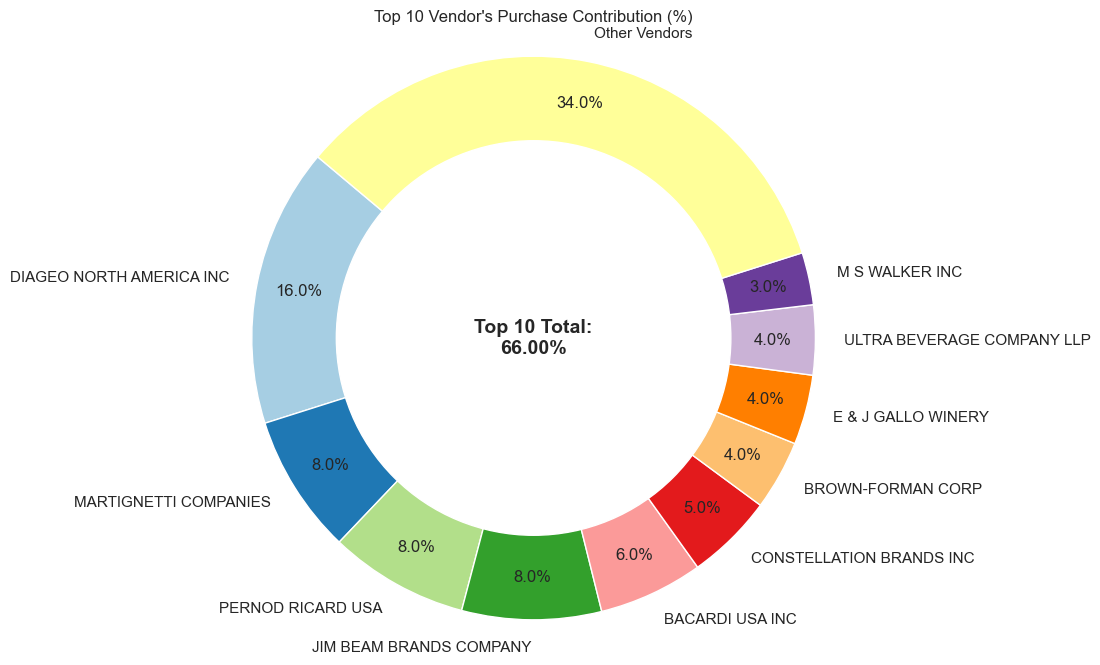

In [177]:
# ==========================================================
# Top 10 Vendor Purchase Contribution (%) - Donut Chart
# ==========================================================

import matplotlib.pyplot as plt

# Prepare Data
vendors = list(top_vendors['VendorName'].values)

# Convert decimal values (0.163) to percentage (16.3)
purchase_contributions = list(top_vendors['PurchaseContribution%'] * 100)

# Total contribution
total_contribution = sum(purchase_contributions)

# Remaining vendors
remaining_contribution = 100 - total_contribution

# Append "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# ==========================================================
# Donut Chart
# ==========================================================

fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Create donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# Center Text
plt.text(
    0,
    0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.axis('equal')

plt.show()

In [178]:
import plotly.graph_objects as go
import plotly.express as px

# ==========================================================
# Prepare Data
# ==========================================================

vendors = top_vendors["VendorName"].tolist()

# Convert decimal values to percentage
purchase_contributions = (top_vendors["PurchaseContribution%"] * 100).tolist()

top10_total = purchase_contributions and sum(purchase_contributions)

remaining_contribution = 100 - top10_total

vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# ==========================================================
# Create Donut Chart
# ==========================================================

fig = go.Figure()

fig.add_trace(
    go.Pie(
        labels=vendors,
        values=purchase_contributions,
        hole=0.68,
        sort=False,
        direction="clockwise",

        # Highlight Top 3 vendors
        pull=[0.05 if i < 3 else 0 for i in range(len(vendors)-1)] + [0],

        marker=dict(
            colors=px.colors.qualitative.Set3,
            line=dict(color="white", width=2)
        ),

        textinfo="label+percent",
        textposition="outside",

        hovertemplate=
        "<b>%{label}</b><br>" +
        "Purchase Contribution: %{value:.2f}%<br>" +
        "Share of Total: %{percent}<extra></extra>"
    )
)

# ==========================================================
# Center KPI
# ==========================================================

fig.add_annotation(
    x=0.5,
    y=0.5,
    text=(
        "<b>Top 10 Total</b><br>"
        f"<span style='font-size:34px;color:#1f77b4'>{top10_total:.2f}%</span>"
    ),
    showarrow=False,
    font=dict(size=18)
)

# ==========================================================
# Layout
# ==========================================================

fig.update_layout(

    template="plotly_white",

    width=1100,
    height=800,

    title=dict(
        text="<b>Top 10 Vendor Purchase Contribution (%)</b>",
        x=0.5,
        xanchor="center",
        font=dict(size=24)
    ),

    font=dict(
        family="Arial",
        size=13,
        color="black"
    ),

    showlegend=False,

    margin=dict(
        l=40,
        r=40,
        t=90,
        b=40
    )
)

fig.show()

In [183]:
#which vendors have low inventory   turnover , indicating excess stock and slow moving products?

In [185]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [186]:
#how much capital is locked in unsold inventory per venor ,a nd which vendors contribute most to it ?
# Calculate the monetary value of unsold inventory

df["UnsoldInventoryValue"] = (
    (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"])
    * df["PurchasePrice"]
)

print(
    "Total Unsold Capital:",
    format_dollars(df["UnsoldInventoryValue"].sum())
)

Total Unsold Capital: 2.71M


In [187]:
# Aggregate Capital Locked per Vendor

inventory_value_per_vendor = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
      .sum()
      .reset_index()
)

# Sort Vendors with the Highest Locked Capital

inventory_value_per_vendor = (
    inventory_value_per_vendor
    .sort_values(
        by="UnsoldInventoryValue",
        ascending=False
    )
)

# Format the monetary values for display

inventory_value_per_vendor["UnsoldInventoryValue"] = (
    inventory_value_per_vendor["UnsoldInventoryValue"]
    .apply(format_dollars)
)

# Display Top 10 Vendors

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


In [188]:
# =============================================================================
# Business Question:
# What are the 95% confidence intervals for the profit margins of
# top-performing vendors and low-performing vendors based on Total Sales Dollars?
# =============================================================================

# Calculate the 75th and 25th percentile sales thresholds

top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Extract Profit Margin values for Top and Low Performing Vendors

top_vendors = (
    df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"]
    .dropna()
)

low_vendors = (
    df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"]
    .dropna()
)

In [189]:
def confidence_interval(data, confidence=0.95):

    mean_val = np.mean(data)

    std_err = np.std(data, ddof=1) / np.sqrt(len(data))

    t_critical = stats.t.ppf(
        (1 + confidence) / 2,
        df=len(data) - 1
    )

    margin_of_error = t_critical * std_err

    return (
        mean_val,
        mean_val - margin_of_error,
        mean_val + margin_of_error
    )

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


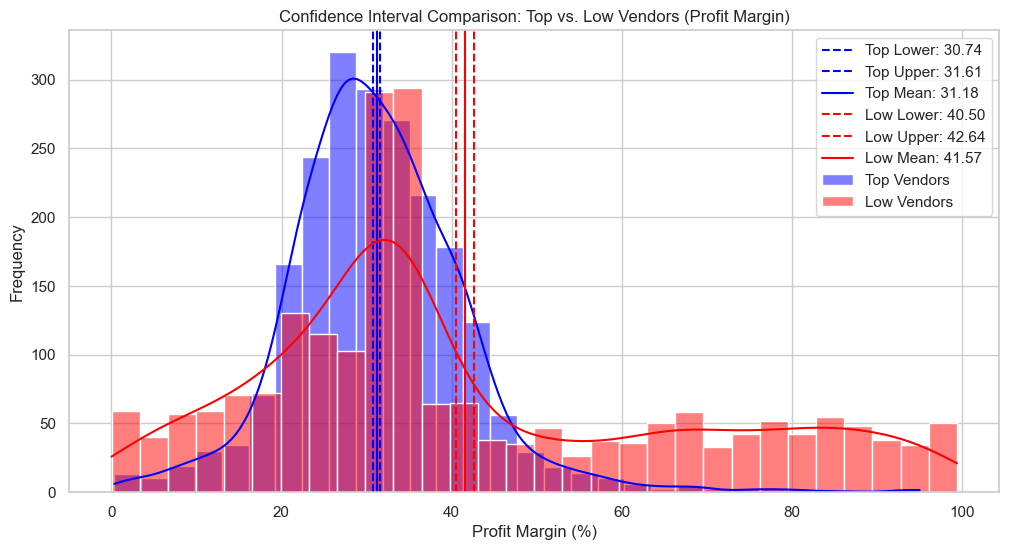

In [190]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [191]:
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
import numpy as np

top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

x = np.linspace(
    min(top_vendors.min(), low_vendors.min()),
    max(top_vendors.max(), low_vendors.max()),
    500
)

top_kde = gaussian_kde(top_vendors)
low_kde = gaussian_kde(low_vendors)

fig = go.Figure()

# ---------------------------
# Top Vendors Distribution
# ---------------------------

fig.add_trace(
    go.Scatter(
        x=x,
        y=top_kde(x),
        mode="lines",
        name="Top Vendors",
        line=dict(color="#1f77b4", width=4),
        fill="tozeroy",
        fillcolor="rgba(31,119,180,0.18)"
    )
)

# ---------------------------
# Low Vendors Distribution
# ---------------------------

fig.add_trace(
    go.Scatter(
        x=x,
        y=low_kde(x),
        mode="lines",
        name="Low Vendors",
        line=dict(color="#d62728", width=4),
        fill="tozeroy",
        fillcolor="rgba(214,39,40,0.18)"
    )
)

# ---------------------------
# Mean Lines
# ---------------------------

fig.add_vline(
    x=top_mean,
    line_width=3,
    line_dash="solid",
    line_color="#1f77b4"
)

fig.add_vline(
    x=low_mean,
    line_width=3,
    line_dash="solid",
    line_color="#d62728"
)

# ---------------------------
# Confidence Interval
# ---------------------------

fig.add_vrect(
    x0=top_lower,
    x1=top_upper,
    fillcolor="#1f77b4",
    opacity=0.10,
    layer="below",
    line_width=0
)

fig.add_vrect(
    x0=low_lower,
    x1=low_upper,
    fillcolor="#d62728",
    opacity=0.10,
    layer="below",
    line_width=0
)

# ---------------------------
# Annotations
# ---------------------------

fig.add_annotation(
    x=top_mean,
    y=max(top_kde(x))*1.05,
    text=f"<b>Top Mean</b><br>{top_mean:.2f}",
    showarrow=True,
    arrowhead=2,
    bgcolor="white"
)

fig.add_annotation(
    x=low_mean,
    y=max(low_kde(x))*0.9,
    text=f"<b>Low Mean</b><br>{low_mean:.2f}",
    showarrow=True,
    arrowhead=2,
    bgcolor="white"
)

# ---------------------------
# Layout
# ---------------------------

fig.update_layout(

    template="plotly_white",

    title=dict(
        text="<b>Profit Margin Distribution with 95% Confidence Intervals</b>",
        x=0.5,
        font=dict(size=24)
    ),

    xaxis=dict(
        title="<b>Profit Margin (%)</b>",
        showgrid=True,
        zeroline=False
    ),

    yaxis=dict(
        title="<b>Density</b>",
        showgrid=True,
        zeroline=False
    ),

    hovermode="x unified",

    legend=dict(
        orientation="h",
        y=1.08,
        x=0.5,
        xanchor="center"
    ),

    font=dict(
        family="Segoe UI",
        size=13
    ),

    width=1200,
    height=700,

    margin=dict(
        l=70,
        r=50,
        t=90,
        b=60
    )
)

fig.show()

In [ ]:
# The 95% confidence interval for low-performing vendors (40.48%–42.62%) is significantly higher than that of top-performing vendors (30.74%–31.61%).

# This indicates that vendors with lower sales tend to maintain higher profit margins, possibly due to premium pricing, niche products, or lower operational costs.

# Business Insight for High-Performing Vendors:
# Improve profitability by optimizing pricing strategies, reducing operational costs, negotiating supplier contracts, or introducing value-added bundles.

# Business Insight for Low-Performing Vendors:
# Although these vendors achieve higher profit margins, their lower sales volume suggests opportunities to improve marketing efforts, enhance product visibility, adopt competitive pricing, or strengthen distribution channels.

In [ ]:
#hypothesis test null and alternative


In [195]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)

low_threshold = df["TotalSalesDollars"].quantile(0.25)


top_vendors = (
    df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"]
    .dropna()
)

low_vendors = (
    df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"]
    .dropna()
)


t_stat, p_value = ttest_ind(
    top_vendors,
    low_vendors,
    equal_var=False
)


print(
    f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}"
)

if p_value < 0.05:
    print(
        "Reject H₀: There is a significant difference in profit margins between top and low-performing vendors."
    )
else:
    print(
        "Fail to Reject H₀: No significant difference in profit margins."
    )

T-Statistic: nan, P-Value: nan
Fail to Reject H₀: No significant difference in profit margins.
